### Application du lisseur pour le traitement de données

In [1]:
use_collab = False # set to true if you use it on google collab

In [2]:
# set to False if you do not have TeX distribution or scienceplots installed with a compatible matplotlib version

usetex = True
use_scienceplots = True

In [3]:
pip install scienceplots

Note: you may need to restart the kernel to use updated packages.


In [4]:
if use_collab:

    from google.colab import drive
    drive.mount('/content/gdrive', force_remount=True)

    folder_name = 'Tunis_F2/Day_2/src/'
    root_dir = '/content/gdrive/My Drive/'
    base_dir = root_dir + folder_name

In [5]:
import numpy as np
import pandas as pd
import os
import sys
import datetime

current_dir = os.getcwd()
if not use_collab:
    base_dir = current_dir
    module_path = os.path.abspath(os.path.join(current_dir, '..', 'libs'))
else:
    module_path = os.path.abspath(os.path.join(base_dir, '..', 'libs'))
if module_path not in sys.path:
    sys.path.append(module_path)

from SCOU_extended_3_1 import *
from utils import *

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [6]:
data = pd.read_csv(base_dir.split('src')[0] + '/data/paris_dataset.csv', sep=";")
data.head()

,plantName,dateStart,obs,lod,plantVolume,meanVolume
0,PARIS_MARNE_AVAL,2020-03-04,12574.599399,5000,112789.0,45468.0
1,PARIS_SEINE-AMONT,2020-03-04,25588.956313,5000,815138.0,452285.0
2,PARIS_SEINE-MOREE,2020-03-05,34534.424360,5000,14818.0,14818.0
3,PARIS_MARNE_AVAL,2020-03-11,317991.056546,5000,94628.0,45468.0
4,PARIS_SEINE-AMONT,2020-03-11,338631.098971,5000,859699.0,452285.0


# Traitement de PARIS_MARNE_AVAL

### Etape 1 : Récupération des lignes qui correspondent à cette station

In [7]:
# Definition du nom de la station
station = 'PARIS_MARNE_AVAL'

# Extraction des lignes correspondant à cette station
sub_data = data.loc[data.plantName==station].copy()

# Suppression de la colonne 'plantName' qui n'a plus d'utilisé car il n'y a qu'une occurence:
sub_data = sub_data.drop('plantName', axis=1)

# Affichage des 5 premières lignes:
sub_data.head()

,dateStart,obs,lod,plantVolume,meanVolume
0,2020-03-04,1.257460e+04,5000,112789.0,45468.0
3,2020-03-11,3.179911e+05,5000,94628.0,45468.0
6,2020-04-02,2.012538e+06,5000,64924.0,45468.0
8,2020-04-08,7.719616e+05,5000,63475.0,45468.0
13,2020-04-15,6.582997e+05,5000,59714.0,45468.0


### Etape 2 : Remise à un niveau théoriquement plus cohérent des observations inférieures à la lod

In [8]:
sub_data.loc[sub_data.obs<=sub_data.lod]

,dateStart,obs,lod,plantVolume,meanVolume
31,2020-05-04,1640.586721,5000,58126.0,45468.0
37,2020-05-13,2048.383566,5000,57955.0,45468.0
40,2020-05-18,642.264920,5000,55580.0,45468.0
45,2020-05-20,1417.411531,5000,56933.0,45468.0
48,2020-05-22,2091.685476,5000,56259.0,45468.0
49,2020-05-25,1067.996099,5000,53295.0,45468.0
53,2020-05-27,918.230100,5000,52871.0,45468.0
57,2020-06-01,644.744141,5000,53750.0,45468.0
62,2020-06-04,1482.174872,5000,83846.0,45468.0
65,2020-06-10,877.806265,5000,52457.0,45468.0


In [9]:
sub_data.loc[sub_data.obs<=sub_data.lod, 'obs'] = sub_data.loc[sub_data.obs<=sub_data.lod, 'lod'] 

In [10]:
sub_data.loc[sub_data.obs<=sub_data.lod]

,dateStart,obs,lod,plantVolume,meanVolume
31,2020-05-04,5000.0,5000,58126.0,45468.0
37,2020-05-13,5000.0,5000,57955.0,45468.0
40,2020-05-18,5000.0,5000,55580.0,45468.0
45,2020-05-20,5000.0,5000,56933.0,45468.0
48,2020-05-22,5000.0,5000,56259.0,45468.0
49,2020-05-25,5000.0,5000,53295.0,45468.0
53,2020-05-27,5000.0,5000,52871.0,45468.0
57,2020-06-01,5000.0,5000,53750.0,45468.0
62,2020-06-04,5000.0,5000,83846.0,45468.0
65,2020-06-10,5000.0,5000,52457.0,45468.0


### Etape 3 : Traitement des effets de dilution

In [11]:
# Conversion des volumes de m3 en L :
for col in ['plantVolume', 'meanVolume']:
    sub_data[col] *= 1000

# Passage en flux, puis division par le volume moyen si on souhaite comparer plusieurs stations entre-elles :
#for col in ['obs', 'lod']:
#    sub_data[col] = sub_data[col] * sub_data['plantVolume'] / sub_data['meanVolume']

# Mais ici on ne traite qu'une station. On peut donc se contenter de travailler en flux !
for col in ['obs', 'lod']:
    sub_data[col] = sub_data[col] * sub_data['plantVolume']

sub_data.head()

,dateStart,obs,lod,plantVolume,meanVolume
0,2020-03-04,1.418276e+12,5.639450e+11,112789000.0,45468000.0
3,2020-03-11,3.009086e+13,4.731400e+11,94628000.0,45468000.0
6,2020-04-02,1.306620e+14,3.246200e+11,64924000.0,45468000.0
8,2020-04-08,4.900026e+13,3.173750e+11,63475000.0,45468000.0
13,2020-04-15,3.930971e+13,2.985700e+11,59714000.0,45468000.0


### Etape 4 : Rajout des jours manquants au calendrier

In [12]:
# Conversion de la colonne dateStart au format datetime:
sub_data.dateStart = pd.to_datetime(sub_data.dateStart)

# Rajout des jours au calendrier en une seule ligne de code:
sub_data = sub_data.set_index('dateStart').resample('D').mean().reset_index()

sub_data.head()

,dateStart,obs,lod,plantVolume,meanVolume
0,2020-03-04,1.418276e+12,5.639450e+11,112789000.0,45468000.0
1,2020-03-05,NaN,NaN,NaN,NaN
2,2020-03-06,NaN,NaN,NaN,NaN
3,2020-03-07,NaN,NaN,NaN,NaN
4,2020-03-08,NaN,NaN,NaN,NaN


### Etape 5 : Passage en échelle log pour être conforme avec les hypothèses de l'algorithme de lissage

In [13]:
# Il ne faut pas oublier d'effectuer cette transformation pour la colonne obs ET pour la colonne lod
for col in ['obs', 'lod']:
    sub_data[col] = np.log10(sub_data[col]) # on peut aussi utiliser une autre base que la base log10, mais c'est mieux pour l'interprétation

sub_data.head()

,dateStart,obs,lod,plantVolume,meanVolume
0,2020-03-04,12.151761,11.751237,112789000.0,45468000.0
1,2020-03-05,NaN,NaN,NaN,NaN
2,2020-03-06,NaN,NaN,NaN,NaN
3,2020-03-07,NaN,NaN,NaN,NaN
4,2020-03-08,NaN,NaN,NaN,NaN


### Etape 6 : Utilisation des fonctions prédéfinies pour le lissage

In [14]:
scou = model_fit(sub_data, 'obs', 'lod')

Applying unidimensional model...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 4 jobs)
NUTS: [sig, eps_pcr, p_out_pcr_logit, latent]


Sampling 3 chains for 3_000 tune and 2_000 draw iterations (9_000 + 6_000 draws total) took 139 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Raw summary:
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sig           0.130  0.015   0.102    0.157      0.001    0.001     121.0   
eps_pcr[0]    0.320  0.025   0.273    0.367      0.001    0.001     867.0   
p_out_pcr[0]  0.026  0.009   0.010    0.043      0.000    0.000    6796.0   

              ess_tail  r_hat  
sig              260.0   1.02  
eps_pcr[0]      2950.0   1.00  
p_out_pcr[0]    4660.0   1.00  


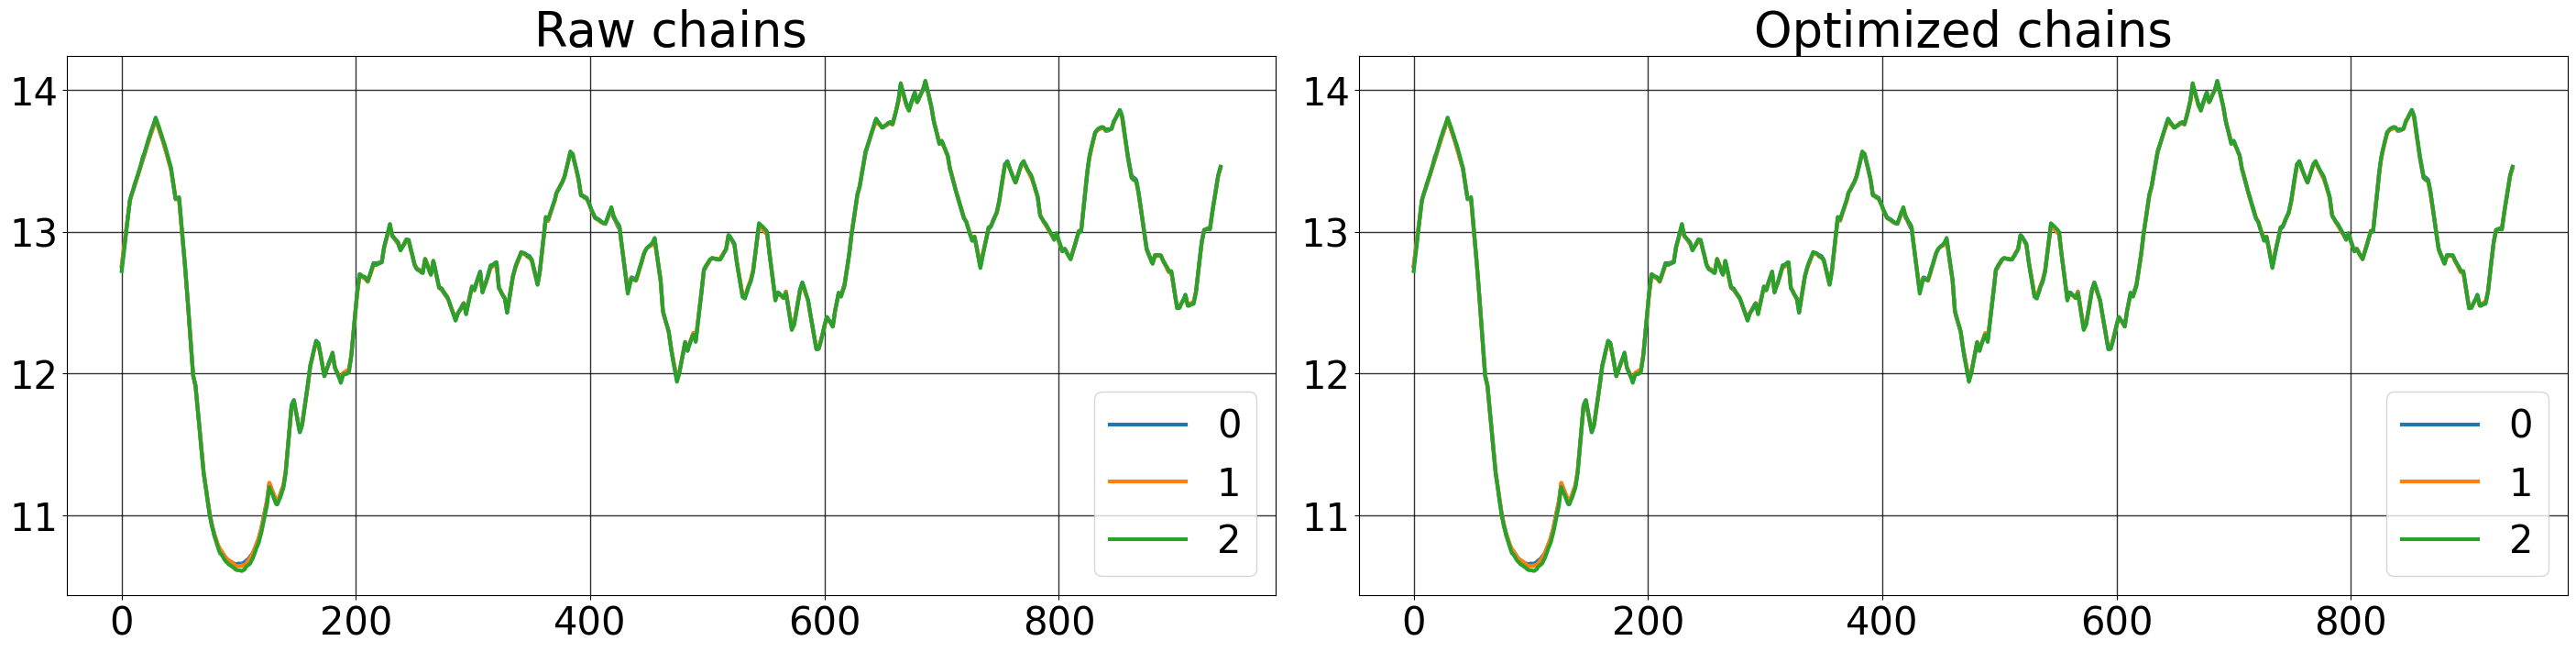

Best chain combination summary:
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sig           0.130  0.015   0.102    0.157      0.001    0.001     121.0   
eps_pcr[0]    0.320  0.025   0.273    0.367      0.001    0.001     867.0   
p_out_pcr[0]  0.026  0.009   0.010    0.043      0.000    0.000    6796.0   

              ess_tail  r_hat  
sig              260.0   1.02  
eps_pcr[0]      2950.0   1.00  
p_out_pcr[0]    4660.0   1.00  


In [15]:
get_results(sub_data, scou, remove_those = [])